In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_excel("EDA.xlsx")


C:\Users\ADITI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
C:\Users\ADITI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)


In [6]:
df.head() 
df.isnull().sum()

Customer_ID                  0
Age                          8
Gender                       7
City                        11
Employment_Type              7
Education                   10
Monthly_Income_INR          18
Years_as_Customer            0
Satisfaction_Score          13
Last_Purchase_Amount_INR    15
Products_Purchased           0
Payment_Method               8
Membership_Level             0
Last_Contact_Date            6
Churn                        0
dtype: int64

In [7]:
invalid_ages = df[(df['Age'] < 0) | (df['Age'] > 110)]
df['Age_Cleaned'] = np.where((df['Age'] < 0) | (df['Age'] > 110), np.nan, df['Age'])

In [10]:
invalid_satisfaction = df[~df['Satisfaction_Score'].between(1, 10)]

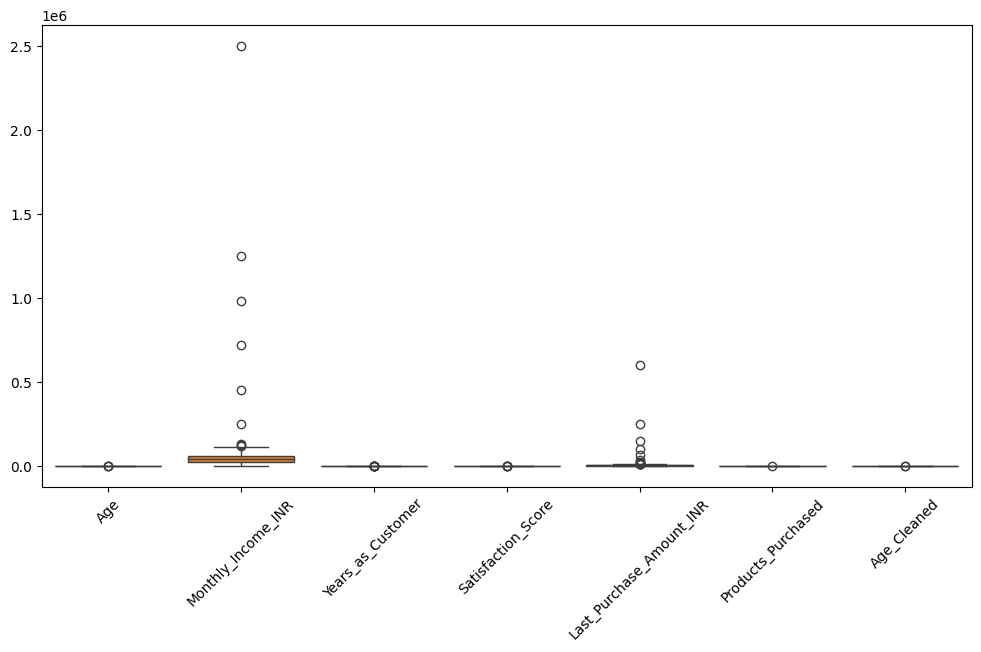

In [11]:
numerical_cols = df.select_dtypes(include=np.number)
Q1 = numerical_cols.quantile(0.25)
Q3 = numerical_cols.quantile(0.75)
IQR = Q3 - Q1
outliers_count = ((numerical_cols < (Q1 - 1.5 * IQR)) | (numerical_cols > (Q3 + 1.5 * IQR))).sum()

plt.figure(figsize=(12, 6))
sns.boxplot(data=numerical_cols)
plt.xticks(rotation=45)
plt.show()

In [13]:
high_value_purchases = df[df['Last_Purchase_Amount_INR'] > (Q3['Last_Purchase_Amount_INR'] + 1.5 * IQR['Last_Purchase_Amount_INR'])]

In [14]:
df['Gender'] = df['Gender'].str.title().replace({'M': 'Male', 'F': 'Female'})
df['Payment_Method'] = df['Payment_Method'].str.upper()
df['City'] = df['City'].str.title()

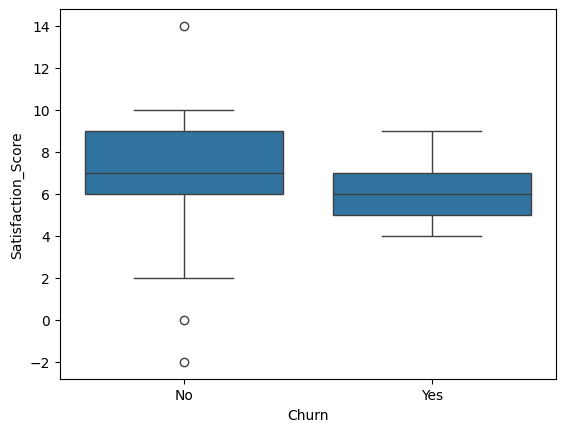

In [22]:
satisfaction_churn = df.groupby('Churn')['Satisfaction_Score'].mean()

sns.boxplot(x='Churn', y='Satisfaction_Score', data=df)
plt.show()

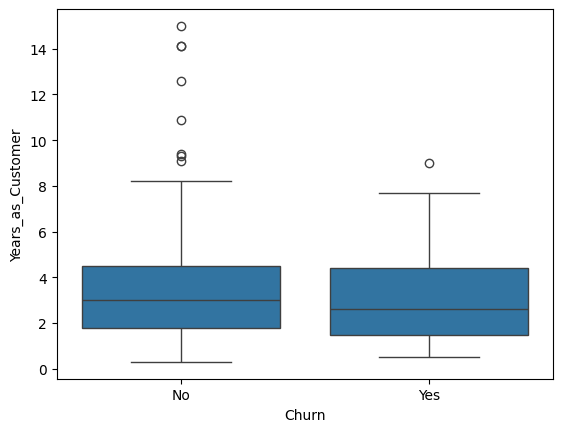

In [27]:
duration_churn = df.groupby('Churn')['Years_as_Customer'].mean()

sns.boxplot(x='Churn', y='Years_as_Customer', data=df)
plt.show()

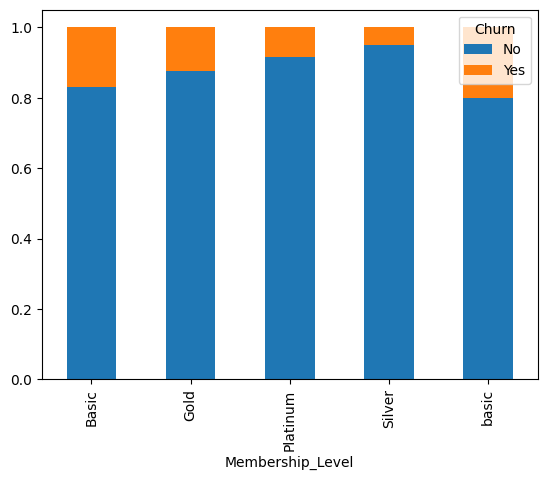

In [28]:
membership_churn = pd.crosstab(df['Membership_Level'], df['Churn'], normalize='index')

membership_churn.plot(kind='bar', stacked=True)
plt.show()

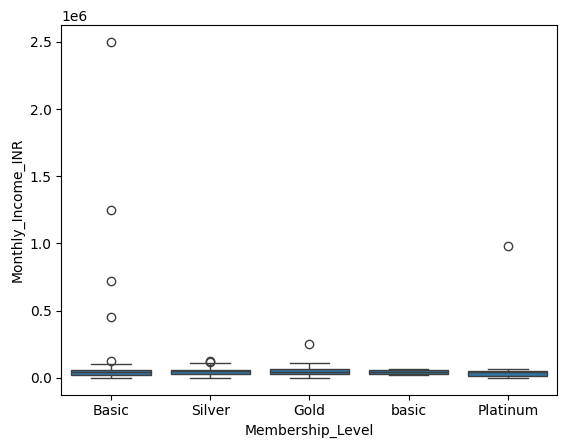

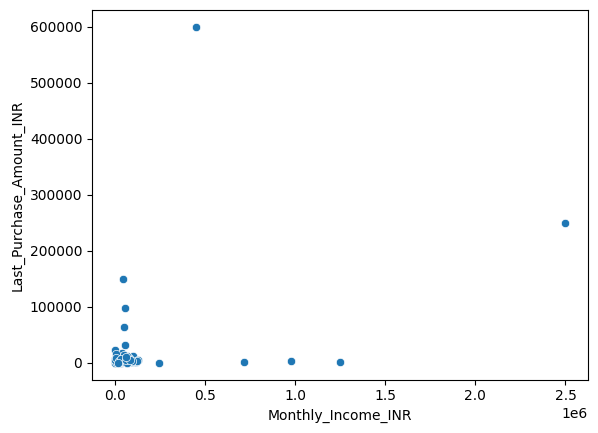

In [31]:
sns.boxplot(x='Membership_Level', y='Monthly_Income_INR', data=df)
plt.show()

sns.scatterplot(x='Monthly_Income_INR', y='Last_Purchase_Amount_INR', data=df)
plt.show()

In [32]:
city_purchases = df.groupby('City')['Last_Purchase_Amount_INR'].mean().sort_values(ascending=False)

In [34]:
payment_purchases = df.groupby('Payment_Method')['Last_Purchase_Amount_INR'].mean()
payment_churn = pd.crosstab(df['Payment_Method'], df['Churn'], normalize='index')


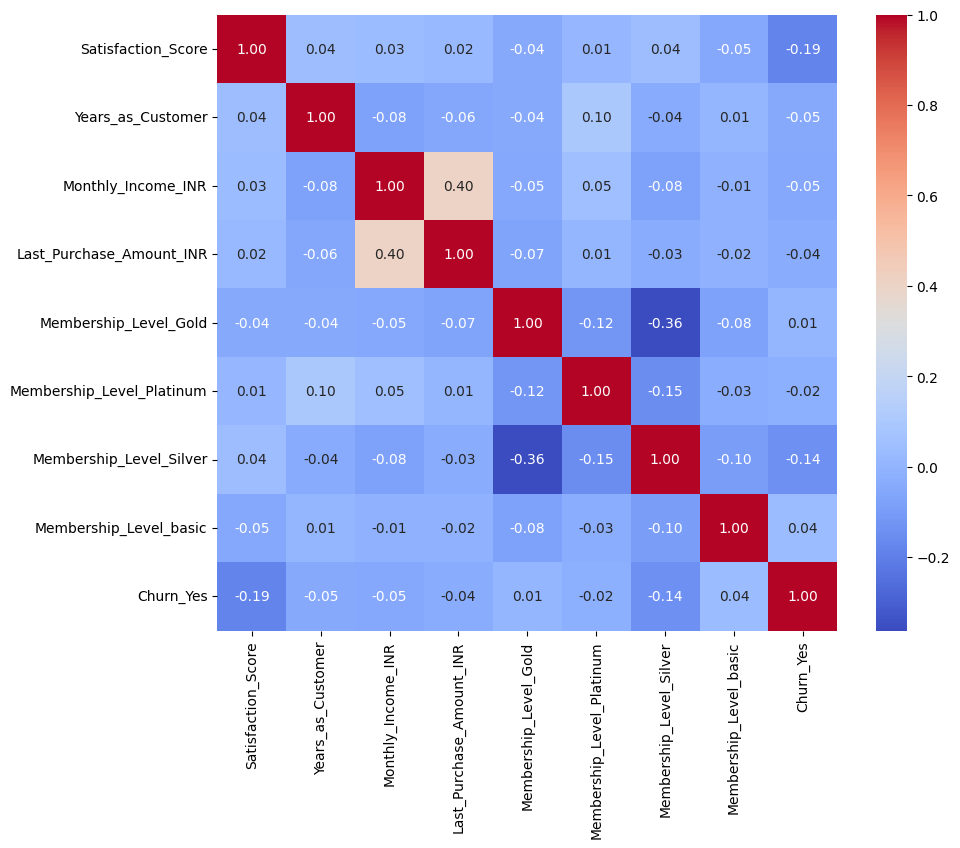

In [38]:
categorical_encoded = pd.get_dummies(df[['Membership_Level', 'Churn']], drop_first=True)
combined_df = pd.concat([df[['Satisfaction_Score', 'Years_as_Customer', 'Monthly_Income_INR', 'Last_Purchase_Amount_INR']], categorical_encoded], axis=1)
correlation_matrix = combined_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()